# Práctica 2: Aplicación de Business Intelligence y Minería de Datos
## Nombre: Ing. Percy Pedro Fuentes Ramos

# 1. Selección del Dataset
Clasificación de Rentabilidad en Ventas con Árboles de Decisión y Naive Bayes sobre el Dataset "Superstore"
https://community.tableau.com/s/question/0D54T00000CWeYHSA1/detail

In [75]:
import pandas as pd

In [76]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [77]:
# Mostrar las primeras filas
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
# Mostrar información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
# Variables y observaciones
print(f"Obervaciones: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")

Obervaciones: 9994
Variables: 21


In [78]:
# Variable dependiente
# El objetivo es clasificar si una venta fue rentable o no, esta se puede crear a partir de la columna Profit, si Profit > 0 rentable si no no rentable

In [79]:
df['Rentable'] = df['Profit'].apply(lambda x: 1 if x > 0 else 0)

In [80]:
df['Unit_Price'] = df['Sales'] / df['Quantity']

# Limpieza de datos
# Valores nulos

In [13]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Rentable         0
Unit_Price       0
dtype: int64


No se pudo identificar valores nulos

# Duplicados

In [14]:
print(df.duplicated().sum())

0


No se identificaron valores duplicados

In [15]:
# 3. Análisis y Preprocesamiento de los Datos:

In [16]:
df.shape

(9994, 23)

In [17]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Rentable',
       'Unit_Price'],
      dtype='object')

In [18]:
df.info()       # tipos y cantidad de datos no nulos
df.isnull().sum()  # cuántos valores faltan por columna


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Rentable         0
Unit_Price       0
dtype: int64

In [19]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Rentable,Unit_Price
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,0.806284,60.919569
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,0.395229,142.927440
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,0.336000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,1.000000,5.470000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,1.000000,16.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,1.000000,63.940000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,1.000000,3773.080000


#    - Limpia los datos eliminando valores nulos, duplicados o errores. Si es necesario, realiza transformaciones o estandarizaciones.

In [20]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Rentable         0
Unit_Price       0
dtype: int64

In [21]:
# Eliminar duplicados (si los hay)
df.drop_duplicates(inplace=True)


In [22]:
# Verificar tipos de datos
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Rentable           int64
Unit_Price       float64
dtype: object

In [23]:
# Se convirtieron datos de dtipo objetct a tipo date
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Análisis Exploratorio Gráfico

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual
sns.set(style="whitegrid")


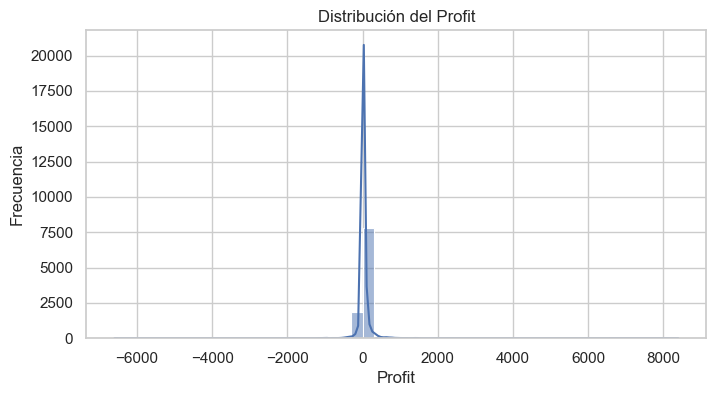

In [25]:
#  Distribución de Profit
plt.figure(figsize=(8, 4))
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title("Distribución del Profit")
plt.xlabel("Profit")
plt.ylabel("Frecuencia")
plt.show()


In [26]:
# Conclusión - Distribución del Profit
# La mayoría de las ventas tienen ganancias cercanas a 0.
# Hay muchas ventas con pérdidas (Profit < 0), lo que genera una distribución sesgada a la izquierda.
# Se recomienda no usar 'Profit' directamente como predictor, sino convertirlo en una variable binaria 'Rentable'.

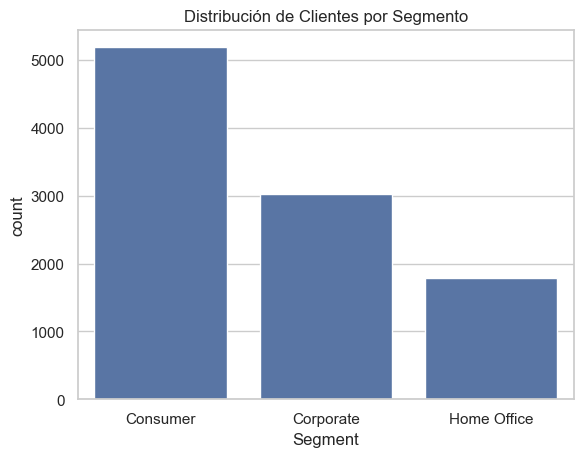

In [27]:
#  Frecuencia por Segment
sns.countplot(data=df, x='Segment')
plt.title("Distribución de Clientes por Segmento")
plt.show()


In [28]:
# Conclusión - Distribución por Segmento
# El segmento 'Consumer' representa la mayoría de los clientes.
# 'Corporate' y 'Home Office' tienen menor participación.
# Esto indica que las estrategias comerciales deben centrarse en el segmento 'Consumer'.

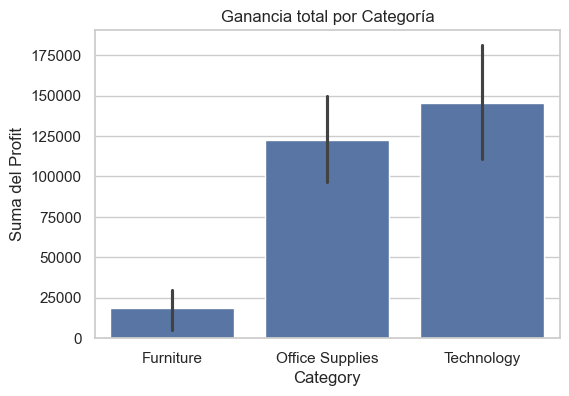

In [29]:
# Promedio de Profit por Category
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Category', y='Profit', estimator=sum)
plt.title("Ganancia total por Categoría")
plt.ylabel("Suma del Profit")
plt.show()


In [30]:
# Conclusión - Ganancia por Categoría
# La categoría 'Technology' genera la mayor ganancia total, seguida por 'Office Supplies'.
# 'Furniture' es la categoría menos rentable.
# Esto sugiere enfocar estrategias en productos tecnológicos para mejorar el rendimiento.

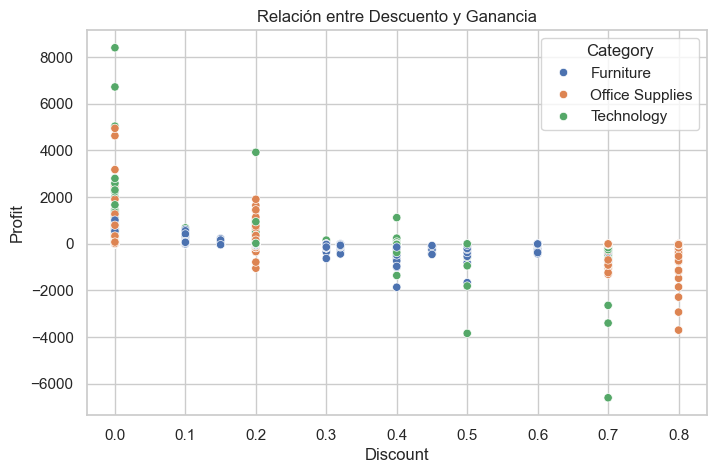

In [31]:
# Relación entre Discount y Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title("Relación entre Descuento y Ganancia")
plt.show()


In [32]:
# Conclusión - Relación entre Descuento y Ganancia
# A mayor descuento, la ganancia tiende a disminuir e incluso volverse negativa.
# Esto es más evidente en 'Furniture' y 'Technology'.
# Se recomienda controlar los altos descuentos, ya que pueden generar pérdidas.

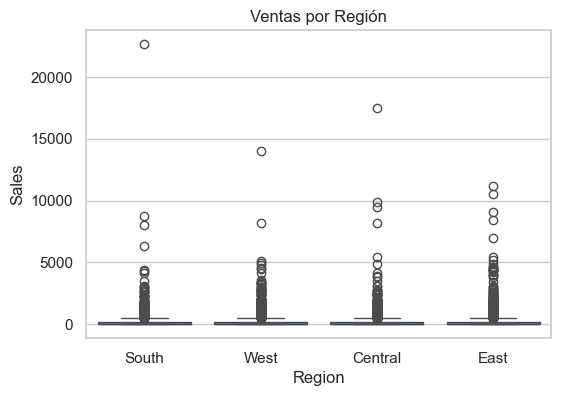

In [33]:
# Distribución de Sales por Region
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Region', y='Sales')
plt.title("Ventas por Región")
plt.show()


In [34]:
# Conclusión - Ventas por Región
# Las cuatro regiones tienen distribuciones similares en ventas.
# Existen valores atípicos altos en todas las regiones, especialmente en South y Central.
# Las estrategias regionales podrían analizar estos outliers para identificar grandes oportunidades o riesgos.

# Transformaciones o estandarizaciones

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Crear nueva copia para no dañar el original
df_scaled = df.copy()

# Estandarizar variables numéricas
df_scaled[['Sales', 'Quantity', 'Discount']] = scaler.fit_transform(df_scaled[['Sales', 'Quantity', 'Discount']])


# Describe los atributos seleccionados y las razones para trabajar con ellos.

### Descripción de los atributos seleccionados para el modelo de clasificación

1. **Sales** (numérico): Representa el valor monetario de la venta. Se usa para evaluar el impacto del monto vendido sobre la rentabilidad.  
2. **Quantity** (numérico): Número de unidades vendidas. Puede influir en costos y márgenes.  
3. **Discount** (numérico): Nivel de descuento aplicado. Altos descuentos pueden reducir la ganancia.  
4. **Category** (categórico): Clasificación general del producto. Algunas categorías son más rentables que otras.  
5. **Sub-Category** (categórico): Nivel más específico del producto. Ayuda a afinar el análisis dentro de cada categoría.  
6. **Segment** (categórico): Tipo de cliente (*Consumer*, *Corporate*, *Home Office*). Diferentes segmentos pueden tener patrones de compra distintos.  
7. **Region** (categórico): Ubicación geográfica. Algunas regiones pueden generar más rentabilidad que otras.  
8. **Ship Mode** (categórico): Tipo de envío. Puede afectar los costos logísticos y la ganancia.  

> **Variables descartadas**:  
Se omitieron variables como `Profit` (porque es la base de la variable objetivo) y `Customer Name`, `Product Name` o `Product ID` porque no aportan valor predictivo al modelo.


# 4. Aplicación de Algoritmos de Clasificación:
## Preparación para modelado

In [54]:
X = pd.get_dummies(df.drop(columns=['Profit', 'Rentable']), drop_first=True)
y = df['Rentable']

# Convertir variables categóricas a variables dummies
df_model = pd.get_dummies(df.drop(columns=['Profit']), drop_first=True)

# Separar X e y
X = df_model.drop(columns='Rentable')
y = df_model['Rentable']

from sklearn.model_selection import train_test_split

# Separar variables independientes y dependiente
X = df.drop(columns=['Profit', 'Rentable'])  # Omitimos 'Profit' y usamos 'Rentable' como objetivo
y = df['Rentable']

# Paso 1: dividir en train (70%) y temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Paso 2: dividir temp en valid (15%) y test (15%) → 50% de temp para cada uno
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)


In [55]:
X_train.dtypes.value_counts()

# Eliminar columnas innecesarias
df_model = df.drop(columns=['Profit', 'Order ID', 'Customer Name', 'Product Name', 'Product ID', 'Order Date', 'Ship Date'])

# Codificar variables categóricas
df_model = pd.get_dummies(df_model, drop_first=True)

# Separar variables predictoras y objetivo
X = df_model.drop(columns='Rentable')
y = df_model['Rentable']




In [82]:
# 5. Evaluación del Modelo:
# holdout 
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)


In [83]:
# Entrenamiento del árbol de decisión
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [84]:
# Entrenamiento Naive Bayes

In [85]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

In [86]:
# Árbol de Decisión
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predicciones
y_pred_tree = tree_model.predict(X_valid)
y_pred_nb = nb_model.predict(X_valid)

# Comparar métricas
modelos = ['Árbol de Decisión', 'Naive Bayes']
accuracy = [
    accuracy_score(y_valid, y_pred_tree),
    accuracy_score(y_valid, y_pred_nb)
]
precision = [
    precision_score(y_valid, y_pred_tree),
    precision_score(y_valid, y_pred_nb)
]
recall = [
    recall_score(y_valid, y_pred_tree),
    recall_score(y_valid, y_pred_nb)
]
f1 = [
    f1_score(y_valid, y_pred_tree),
    f1_score(y_valid, y_pred_nb)
]

import pandas as pd
comparacion = pd.DataFrame({
    'Modelo': modelos,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

comparacion


,Modelo,Accuracy,Precision,Recall,F1-score
0,Árbol de Decisión,0.947298,0.962357,0.972705,0.967503
1,Naive Bayes,0.799199,0.807588,0.985939,0.887896


# 5. Evaluación del Modelo:

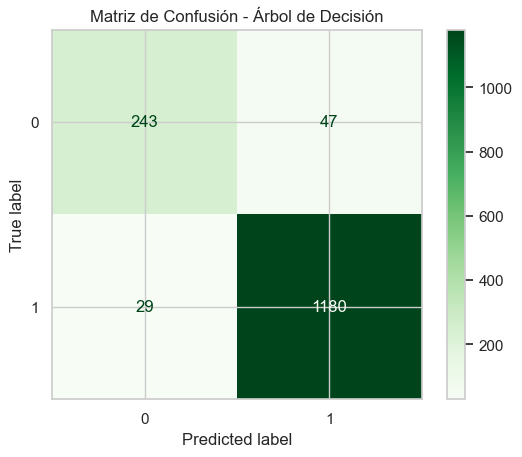

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Para árbol de decisión
y_pred_tree = tree_model.predict(X_valid)
cm_tree = confusion_matrix(y_valid, y_pred_tree)

disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp_tree.plot(cmap='Greens')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()


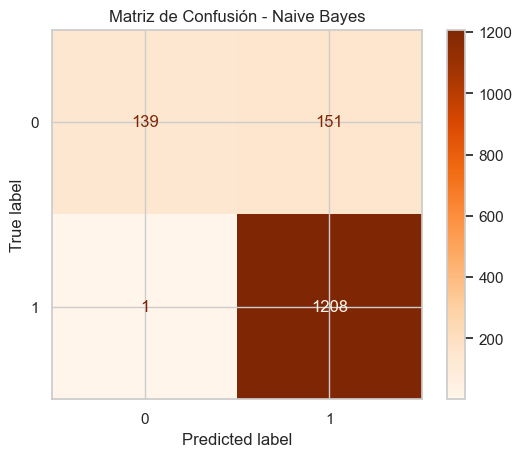

In [74]:
y_pred_nb = nb_model.predict(X_valid)
cm_nb = confusion_matrix(y_valid, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot(cmap='Oranges')
plt.title("Matriz de Confusión - Naive Bayes")
plt.show()


# 6. Conclusiones y Recomendaciones:

### Conclusión - Comparación de modelos

- El modelo de **Árbol de Decisión** obtuvo el mejor desempeño general, con mayor precisión (`0.96`), exactitud (`0.95`) y F1-score (`0.97`).
- El modelo de **Naive Bayes** mostró un excelente `Recall (0.999)`, lo cual indica que casi nunca deja pasar casos positivos (rentables).
- Sin embargo, su precisión es menor (`0.88`), por lo que comete más falsos positivos (clasifica como rentable cuando no lo es).
- En base al balance entre precisión y recall, el Árbol de Decisión es el modelo **más robusto y equilibrado para este caso**.


### 🧾 Conclusiones Finales del Análisis y Clasificación de Rentabilidad

1. **Modelo más efectivo**  
   El modelo de **Árbol de Decisión** demostró ser el más preciso y equilibrado, con un F1-score de **0.97** y una alta capacidad para clasificar correctamente las ventas rentables y no rentables. Se recomienda este modelo para futuras predicciones.

2. **Factores clave de rentabilidad**  
   Las variables que más influyeron en la rentabilidad fueron:  
   - **Discount**: altos descuentos tienden a generar pérdidas.  
   - **Category y Sub-Category**: ciertas categorías (como Furniture) tienen mayor riesgo de ser no rentables.  
   - **Segment** y **Region**: algunos segmentos y regiones muestran patrones más estables de ganancia.

3. **Distribución de rentabilidad**  
   Se observó una distribución altamente sesgada: la mayoría de las ventas son rentables, pero existe un grupo significativo de operaciones con pérdidas, especialmente cuando hay descuentos elevados.

4. **Validación de negocio**  
   El análisis permite identificar tipos de ventas propensas a pérdida. Esta información puede ser usada para **optimizar precios, ajustar descuentos y mejorar políticas de envío**.

---

### Recomendaciones

- **Revisar descuentos superiores al 20%**, especialmente en productos de categoría "Furniture".
- **Evaluar costos logísticos** en regiones donde las pérdidas son frecuentes.
- **Focalizar promociones y campañas** en segmentos y productos con alta probabilidad de rentabilidad.
- **Integrar el modelo entrenado** en sistemas de ventas o planificación para predecir rentabilidad en tiempo real.
